# 02 - Model Results

Compare baseline, strict classical CV, and ResNet50 temporal-head results.

In [1]:
from pathlib import Path
import json
import sys

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

sns.set_theme(style='whitegrid')

In [2]:
summary_path = ROOT / 'artifacts/reports/model_summary.csv'
summary = pd.read_csv(summary_path).sort_values('macro_f1', ascending=False)
summary

,model,accuracy,macro_f1,weighted_f1,high_recall
0,deep_resnet50,0.645161,0.642275,0.644211,0.741935
1,classical_random_forest,0.580645,0.569283,0.573232,0.774194
2,classical_linear_svm,0.559140,0.559293,0.563525,0.677419
3,classical_logistic_regression,0.548387,0.538619,0.544543,0.741935
4,baseline,0.397849,0.189744,0.226468,0.000000


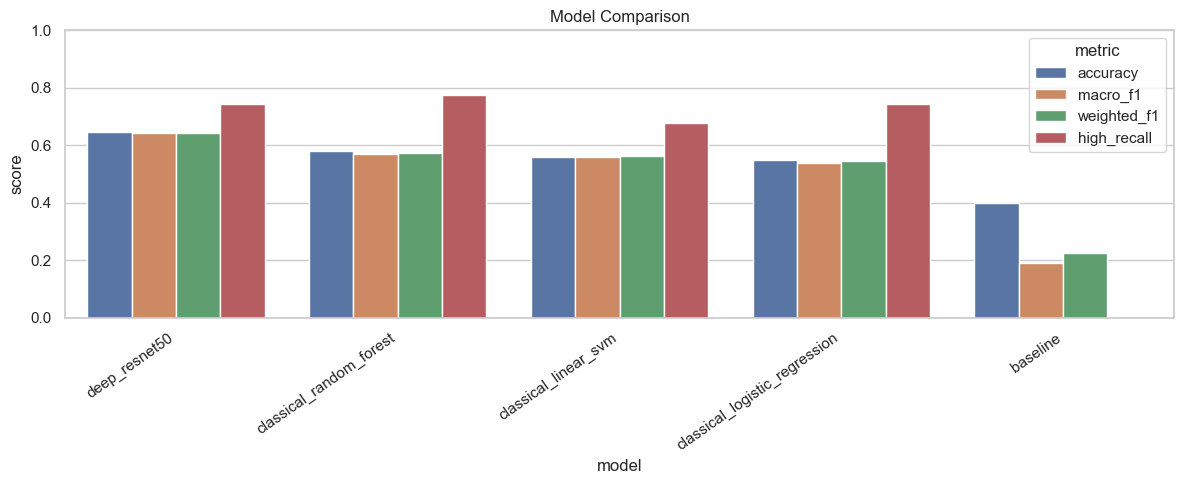

In [3]:
melted = summary.melt(id_vars='model', value_vars=['accuracy', 'macro_f1', 'weighted_f1', 'high_recall'], var_name='metric', value_name='score')
plt.figure(figsize=(12, 5))
sns.barplot(data=melted, x='model', y='score', hue='metric')
plt.xticks(rotation=35, ha='right')
plt.ylim(0, 1)
plt.title('Model Comparison')
plt.tight_layout()

Baseline


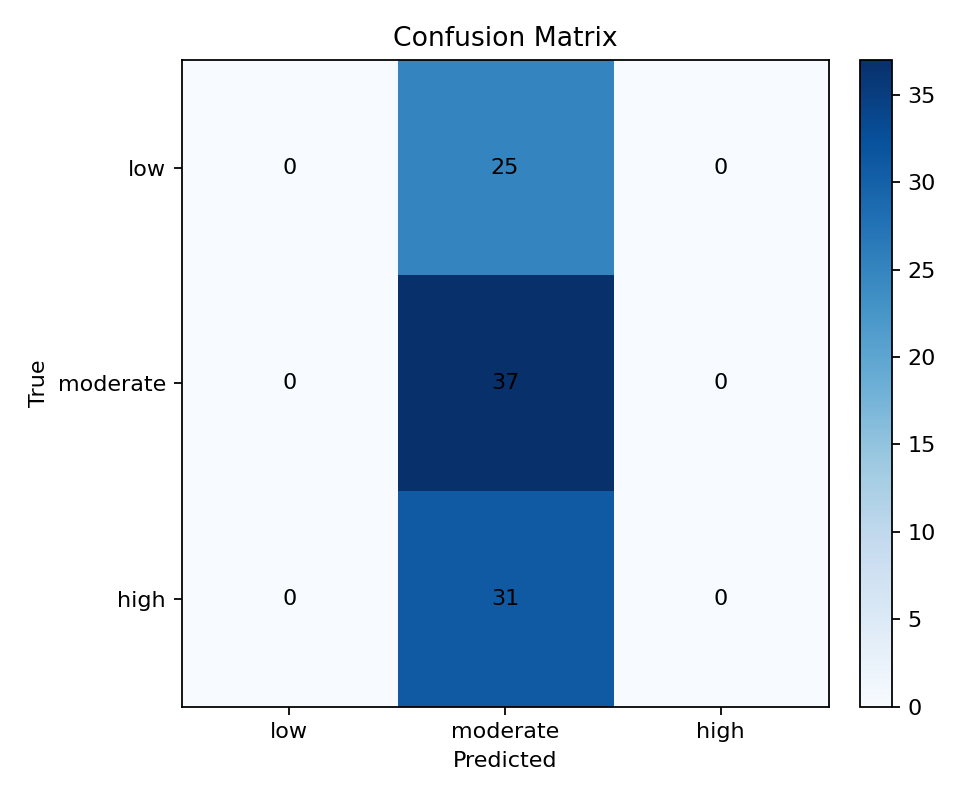

Best Classical CV


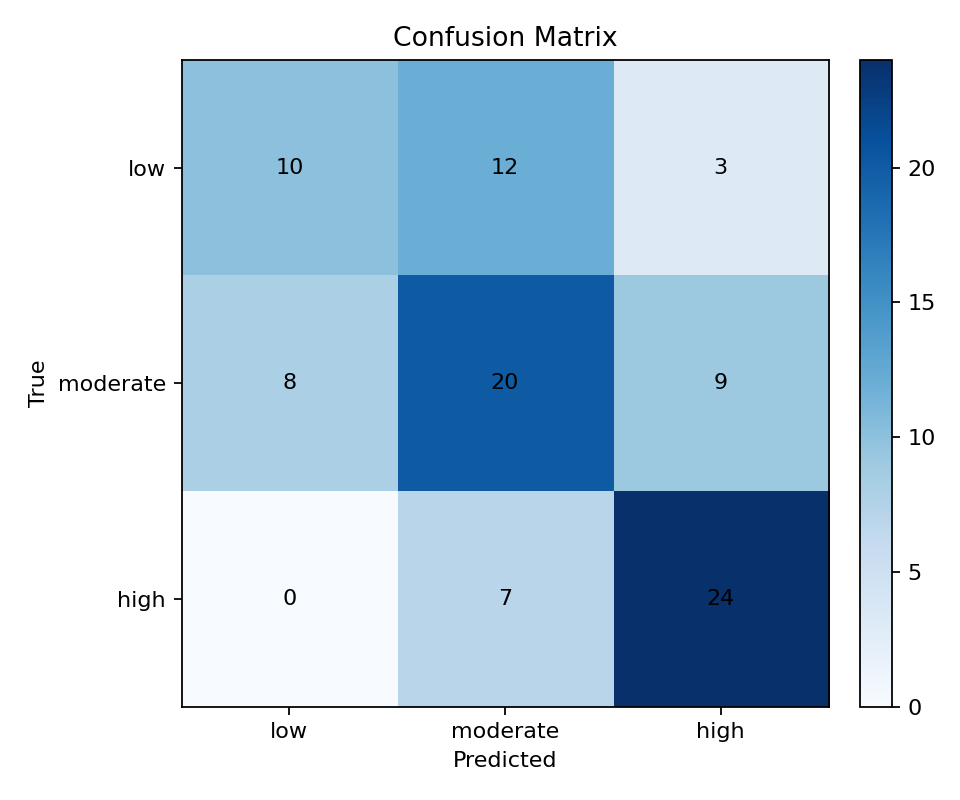

Deep ResNet50


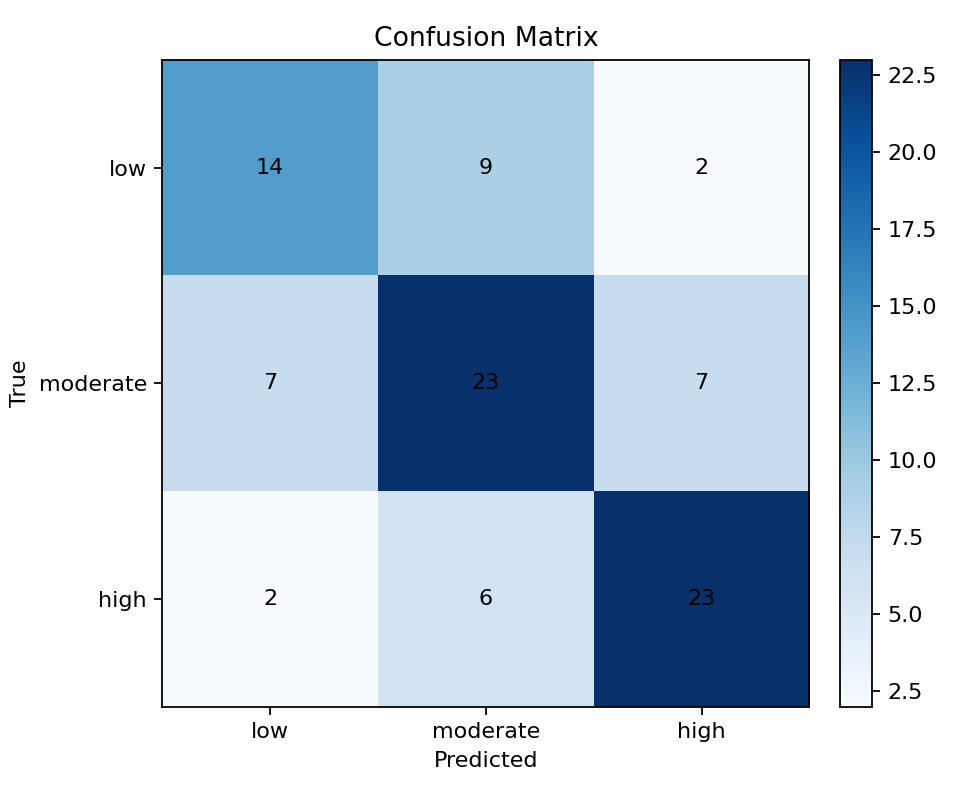

In [4]:
for title, path in {
    'Baseline': ROOT / 'artifacts/models/baseline/confusion_matrix.png',
    'Best Classical CV': ROOT / 'artifacts/models/classical/random_forest_confusion_matrix.png',
    'Deep ResNet50': ROOT / 'artifacts/models/deep_resnet50/confusion_matrix.png',
}.items():
    print(title)
    display(Image(filename=str(path)))

## Transformation Experiment

This focused experiment compares plain HOG + motion features against CLAHE contrast-normalized HOG + motion features.

In [5]:
transform_summary = pd.read_csv(ROOT / 'artifacts/experiments/transformations/summary.csv')
transform_summary

,model,accuracy,macro_f1,weighted_f1,high_recall
0,contrast_normalized_random_forest,0.612903,0.609470,0.609131,0.774194
1,plain_random_forest,0.580645,0.569283,0.573232,0.774194
2,contrast_normalized_logistic_regression,0.569892,0.563333,0.567204,0.774194
3,plain_linear_svm,0.559140,0.559293,0.563525,0.677419
4,contrast_normalized_linear_svm,0.559140,0.557549,0.558277,0.709677
5,plain_logistic_regression,0.548387,0.538619,0.544543,0.741935


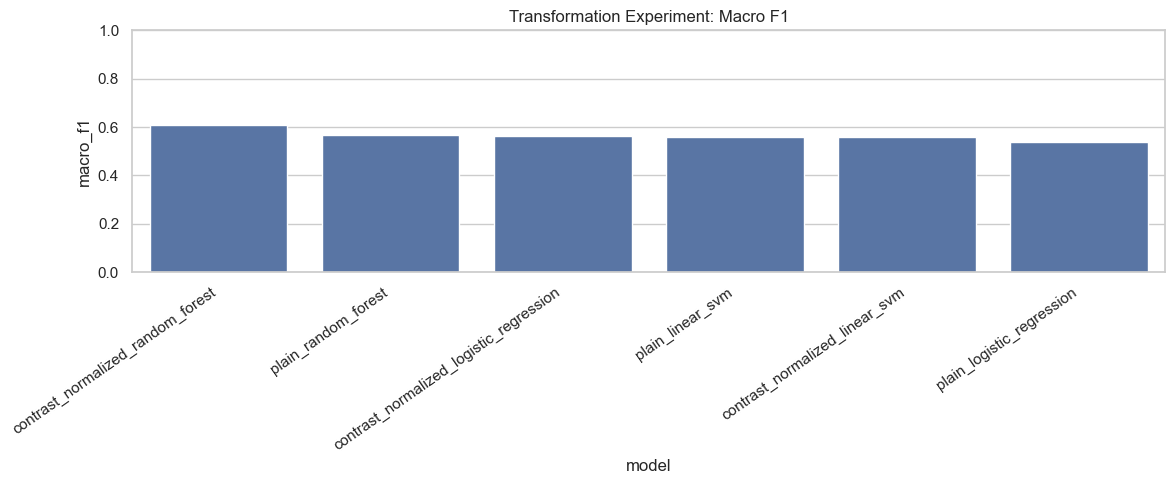

In [6]:
plt.figure(figsize=(12, 5))
sns.barplot(data=transform_summary, x='model', y='macro_f1')
plt.xticks(rotation=35, ha='right')
plt.ylim(0, 1)
plt.title('Transformation Experiment: Macro F1')
plt.tight_layout()